   Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0       522         7.93   Windy           Low   Afternoon      Scooter   
1       738        16.42   Clear        Medium     Evening         Bike   
2       741         9.52   Foggy           Low       Night      Scooter   
3       661         7.44   Rainy        Medium   Afternoon      Scooter   
4       412        19.03   Clear           Low     Morning         Bike   

   Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
0                    12                     1.0                 43  
1                    20                     2.0                 84  
2                    28                     1.0                 59  
3                     5                     1.0                 37  
4                    16                     5.0                 68  

Dataset Shape:
(1000, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (

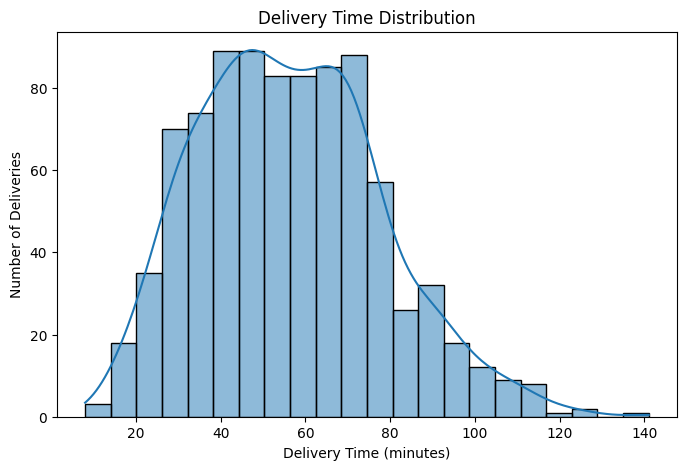

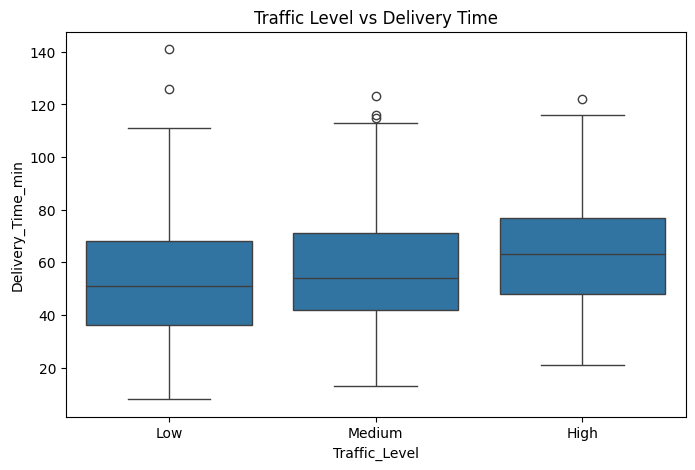

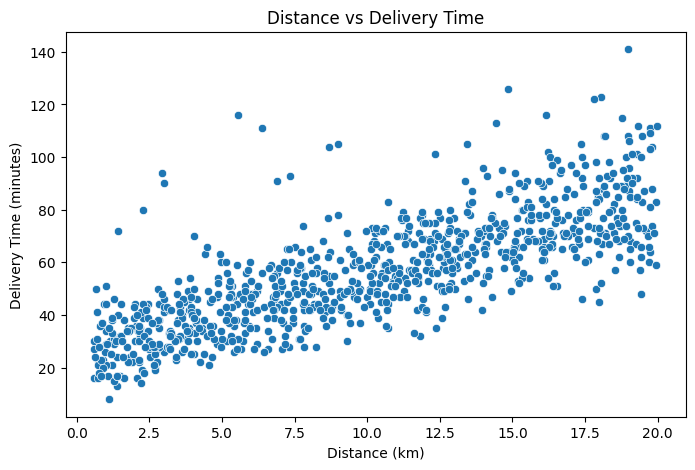


========== ORIGINAL MODEL ==========
Train MAE: 5.0943098068237305
Test MAE: 6.564431190490723
Train R2: 0.8760374784469604
Test R2: 0.7911635637283325

Top 10 Features:
Distance_km               0.391478
Preparation_Time_min      0.099814
Traffic_Level_High        0.080994
Weather_Clear             0.079760
Weather_Foggy             0.061489
Traffic_Level_Low         0.049845
Vehicle_Type_Bike         0.048695
Vehicle_Type_Car          0.034112
Time_of_Day_Evening       0.030914
Courier_Experience_yrs    0.028974
dtype: float32


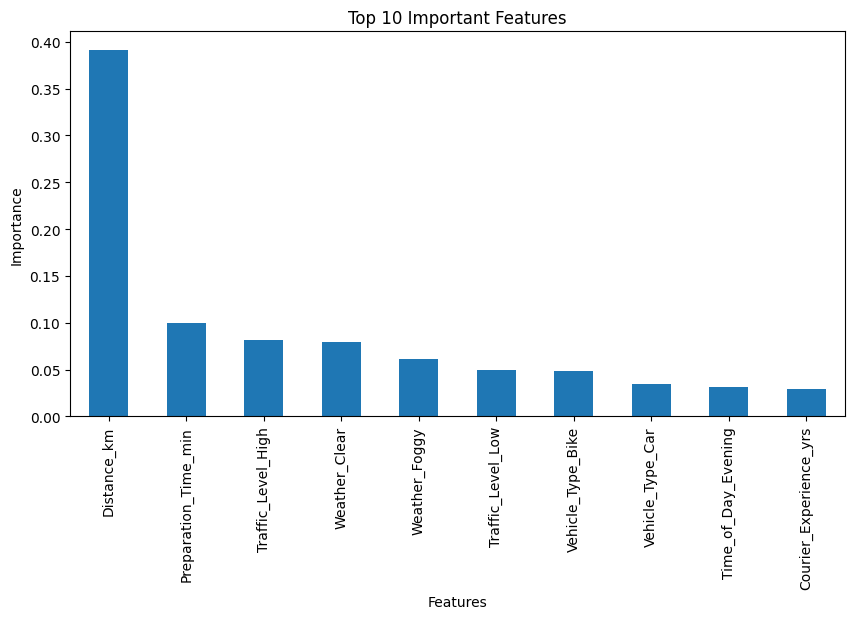


========== BEST PARAMETERS ==========
{'subsample': 0.8, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

========== TUNED MODEL ==========
Train MAE: 5.485354900360107
Test MAE: 6.1510515213012695
Train R2: 0.8505788445472717
Test R2: 0.8046692609786987

========== GENERALIZATION ==========
MAE Gap: 0.6656966209411621
R2 Gap: 0.045909583568573
Model is generalizing well.


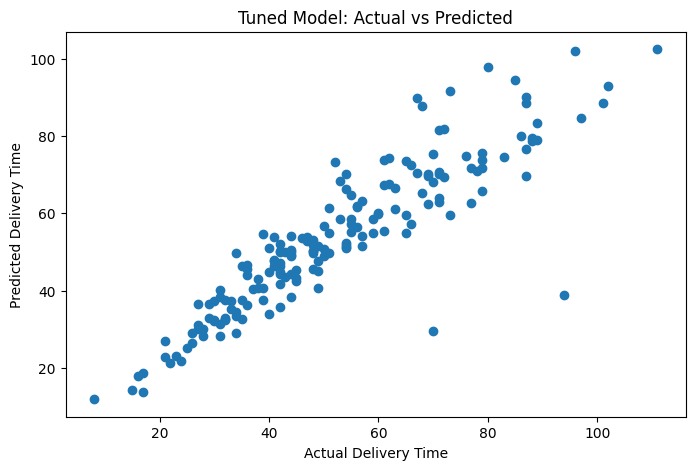


Top 10 Features - Tuned Model:
Distance_km               0.296908
Weather_Clear             0.120755
Preparation_Time_min      0.108302
Traffic_Level_High        0.099235
Traffic_Level_Low         0.061641
Weather_Foggy             0.042109
Weather_Snowy             0.032192
Courier_Experience_yrs    0.028269
Time_of_Day_Evening       0.028139
Time_of_Day_Afternoon     0.023620
dtype: float32


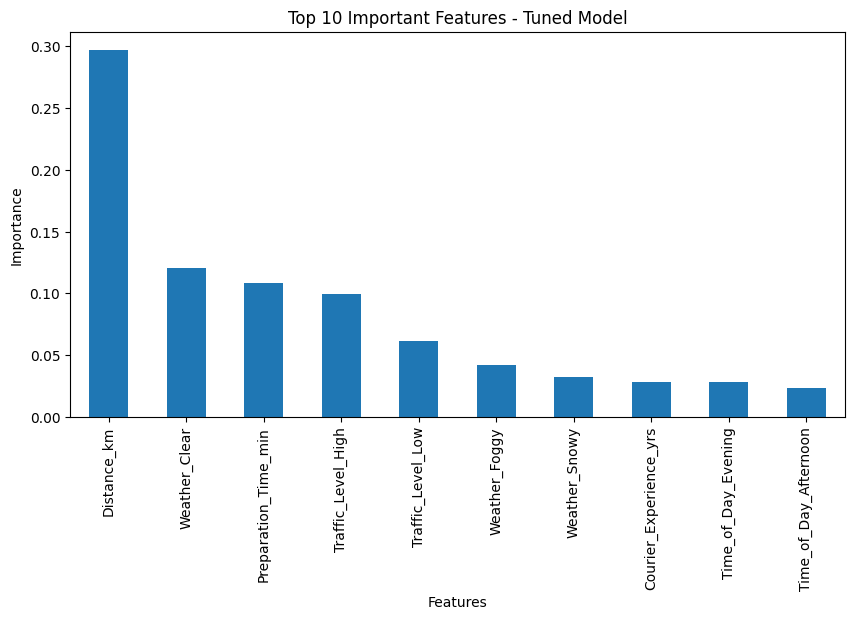


========== FINAL COMPARISON ==========

Original Model:
Train MAE: 5.0943098068237305
Test MAE: 6.564431190490723
Train R2: 0.8760374784469604
Test R2: 0.7911635637283325

Tuned Model:
Train MAE: 5.485354900360107
Test MAE: 6.1510515213012695
Train R2: 0.8505788445472717
Test R2: 0.8046692609786987

Generalization:
MAE Gap: 0.6656966209411621
R2 Gap: 0.045909583568573


In [ ]:
# 1. Import Libraries

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor


# 2. Load Dataset

df = pd.read_csv("/content/Food_Delivery_Times.csv")

print(df.head())


# 3. Understand Dataset

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


# 4. Target

target = "Delivery_Time_min"


# 5. Handle Missing Values

df = df.dropna()

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


# 6. Delivery Time Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Delivery_Time_min"],
    kde=True
)

plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Deliveries")

plt.show()


# 7. Traffic vs Delivery Time

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Traffic_Level",
    y="Delivery_Time_min",
    data=df
)

plt.title("Traffic Level vs Delivery Time")

plt.show()


# 8. Distance vs Delivery Time

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="Distance_km",
    y="Delivery_Time_min",
    data=df
)

plt.title("Distance vs Delivery Time")

plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (minutes)")

plt.show()


# 9. X and y

X = df.drop(
    target,
    axis=1
)

y = df[target]


# 10. Categorical Encoding

X = pd.get_dummies(X)


# 11. Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# 12. Original XGBoost Model

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)


# 13. Train Original Model

model.fit(
    X_train,
    y_train
)


# 14. Original Train Prediction

y_train_pred = model.predict(
    X_train
)


# 15. Original Test Prediction

y_test_pred = model.predict(
    X_test
)


# 16. Original Train Metrics

train_mae = mean_absolute_error(
    y_train,
    y_train_pred
)

train_r2 = r2_score(
    y_train,
    y_train_pred
)


# 17. Original Test Metrics

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

test_r2 = r2_score(
    y_test,
    y_test_pred
)


# 18. Original Model Results

print("\n========== ORIGINAL MODEL ==========")

print("Train MAE:", train_mae)
print("Test MAE:", test_mae)

print("Train R2:", train_r2)
print("Test R2:", test_r2)


# 19. Feature Importance

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

print("\nTop 10 Features:")
print(importance.head(10))


# 20. Feature Importance Plot

importance.head(10).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()


# 21. Hyperparameter Search Space

param_grid = {
    "n_estimators": [100, 200, 300, 400, 500],

    "learning_rate": [0.01, 0.03, 0.05, 0.1],

    "max_depth": [2, 3, 4, 5, 6],

    "min_child_weight": [1, 3, 5, 7],

    "subsample": [0.7, 0.8, 0.9, 1.0],

    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}


# 22. Randomized Search

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=42
    ),

    param_distributions=param_grid,

    n_iter=30,

    cv=3,

    scoring="neg_mean_absolute_error",

    random_state=42,

    n_jobs=-1
)


# 23. Train Randomized Search

random_search.fit(
    X_train,
    y_train
)


# 24. Best Parameters


print(
    random_search.best_params_
)


# 25. Best Model

best_model = random_search.best_estimator_


# 26. Tuned Train Prediction

y_train_pred_tuned = best_model.predict(
    X_train
)


# 27. Tuned Test Prediction

y_test_pred_tuned = best_model.predict(
    X_test
)


# 28. Tuned Train Metrics

train_mae_tuned = mean_absolute_error(
    y_train,
    y_train_pred_tuned
)

train_r2_tuned = r2_score(
    y_train,
    y_train_pred_tuned
)


# 29. Tuned Test Metrics

test_mae_tuned = mean_absolute_error(
    y_test,
    y_test_pred_tuned
)

test_r2_tuned = r2_score(
    y_test,
    y_test_pred_tuned
)


# 30. Tuned Model Results


print("Train MAE:", train_mae_tuned)
print("Test MAE:", test_mae_tuned)

print("Train R2:", train_r2_tuned)
print("Test R2:", test_r2_tuned)


# 31. Generalization Gap

mae_gap = test_mae_tuned - train_mae_tuned

r2_gap = train_r2_tuned - test_r2_tuned



print("MAE Gap:", mae_gap)

print("R2 Gap:", r2_gap)


# 32. Generalization Interpretation

if r2_gap < 0.05:
    print("Model is generalizing well.")

elif r2_gap < 0.10:
    print("Model has a moderate generalization gap.")

else:
    print("Model may be overfitting.")


# 33. Actual vs Predicted

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_test_pred_tuned
)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")

plt.title("Tuned Model: Actual vs Predicted")

plt.show()


# 34. Tuned Feature Importance

tuned_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)

tuned_importance = tuned_importance.sort_values(
    ascending=False
)

print("\nTop 10 Features - Tuned Model:")

print(
    tuned_importance.head(10)
)


# 35. Tuned Feature Importance Plot

tuned_importance.head(10).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(
    "Top 10 Important Features - Tuned Model"
)

plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()


# 36. Final Comparison

print("\nOriginal Model:")

print("Train MAE:", train_mae)
print("Test MAE:", test_mae)
print("Train R2:", train_r2)
print("Test R2:", test_r2)

print("\nTuned Model:")

print("Train MAE:", train_mae_tuned)
print("Test MAE:", test_mae_tuned)
print("Train R2:", train_r2_tuned)
print("Test R2:", test_r2_tuned)

print("\nGeneralization:")

print("MAE Gap:", mae_gap)
print("R2 Gap:", r2_gap)